# Table of Contents
    0 - Prelude
    1 - Data Preprocessing
        1.1 - FAO FRA: Carbon in Above Ground Biomass and Carbon in Below Ground Biomass (AGB/BGB) [1]
            1.1.1 - Data Preprocessing
            1.1.2 - EDA
        1.2 - NOAA: Global Summary of the Year (GSOY) [2]
            1.2.1 - Data Preprocessing
            1.2.2 - EDA
        1.3 - OWID: CO2 Emissions [3]
            1.3.1 - Data Preprocessing
            1.3.2 - EDA

    2 - Join and Split Data

    3 - Machine Learning Models
        3.1 - Linear Regression
        3.2 - Random Forest
        3.3 - PCA
        3.4 - Gradient Boosted Trees
       
    4 - Conclusion

Data References:<br>
[1] https://fra-data.fao.org/assessments/fra/2020/WO/data-download/<br>
[2] https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00947/html<br>
[3] https://ourworldindata.org/co2-and-greenhouse-gas-emissions#explore-data-on-co2-and-greenhouse-gas-emissions <br>

Used to feature engineer in GSOY Dataframe: <br>
https://www.kaggle.com/datasets/vinitasilaparasetty/country-coordinates-world?resource=download

# 0 - Prelude

In [5]:
from pyspark.sql import SparkSession, DataFrame
import re
import subprocess

In [6]:
spark = SparkSession.builder \
    .appName("ForestCarbonAnalysis") \
    .getOrCreate()

sc = spark.sparkContext

HDFS_BASE = "hdfs://namenode:9000"

# 1 - Data Preprocessing

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1.1 - FAO FRA: Carbon in Above Ground Biomass and Carbon in Below Ground Biomass (AGB/BGB)

In [8]:
fra = f"2 Forest growing stock biomass and carbon en.xlsx"

In [9]:
df_agb = pd.read_excel(fra, sheet_name="2d_C_AGB", header=4)
df_bgb = pd.read_excel(fra, sheet_name="2d_C_BGB", header=4)

In [10]:
print(df_agb.head())

  Unnamed: 0 Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  2020  Unnamed: 6  \
0        AGO     Angola         NaN    66607.38         NaN   NaN         NaN   
1        BWA   Botswana         NaN    15254.70         NaN   NaN         NaN   
2        COM    Comoros         NaN       32.92         NaN   NaN         NaN   
3        DJI   Djibouti         NaN        5.80         NaN   NaN         NaN   
4        ERI    Eritrea         NaN     1055.26         NaN   NaN         NaN   

   2020.1  Unnamed: 8  2020.2  ...   90-00.1  90-10.1   90-15.1   90-20.1  \
0   14.40         NaN     NaN  ...  0.000000  0.00000  0.000000  0.000000   
1   72.97         NaN     NaN  ...  0.000000  0.00000  0.000000  0.000000   
2   31.02         NaN     NaN  ...  0.000000  0.00000  0.000000  0.000000   
3   40.66         NaN     NaN  ...  0.000000  0.00000  0.000000 -0.001167   
4   34.08         NaN     NaN  ...  0.000385  0.00034  0.000414  0.000404   

    00-10.1   00-15.1   00-20.1   10-15.1   10-20.

In [11]:
print(df_bgb.head())

  Unnamed: 0 Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  2020  Unnamed: 6  \
0        AGO     Angola         NaN    66607.38         NaN   NaN         NaN   
1        BWA   Botswana         NaN    15254.70         NaN   NaN         NaN   
2        COM    Comoros         NaN       32.92         NaN   NaN         NaN   
3        DJI   Djibouti         NaN        5.80         NaN   NaN         NaN   
4        ERI    Eritrea         NaN     1055.26         NaN   NaN         NaN   

   2020.1  Unnamed: 8  2020.2  ...   90-00.1   90-10.1   90-15.1   90-20.1  \
0    2.88         NaN     NaN  ...  0.000000  0.000000  0.000000  0.000000   
1   20.43         NaN     NaN  ...  0.000000  0.000000  0.000000  0.000000   
2    6.25         NaN     NaN  ...  0.000000  0.000000  0.000000  0.000000   
3   11.38         NaN     NaN  ...  0.000000  0.000000  0.000000 -0.001179   
4    9.45         NaN     NaN  ...  0.000428  0.000321  0.000427  0.000426   

    00-10.1   00-15.1   00-20.1   10-15.1   

### 1.1.1 - Data Preprocessing

In [12]:
def drop_columns(dataset):
    dataset.drop(columns=[
        'Unnamed: 2',
        'Unnamed: 4',
        2020,
        'Unnamed: 6',
        '2020.1',
        'Unnamed: 8',
        '2020.2',
        'Unnamed: 10',
        'Unnamed: 11',
        '90-00',
        '90-10',
        '90-15',
        '90-20',
        '00-10',
        '00-15',
        '00-20',
        '10-15',
        '10-20',
        '15-20',
        '90-00.1',
        '90-10.1',
        '90-15.1',
        '90-20.1',
        '00-10.1',
        '00-15.1',
        '00-20.1',
        '10-15.1',
        '10-20.1',
        '15-20.1'
    ], inplace=True)

In [13]:
def rename_columns(dataset):
    dataset.rename(columns={
        'Unnamed: 0': 'country_code',
        'Unnamed: 1': 'country',
        'Unnamed: 3': 'forest_area_2020',
        1990: 'carbon_1990',
        2000: 'carbon_2000',
        2010: 'carbon_2010',
        2015: 'carbon_2015',
        '2020.3': 'carbon_2020'
    }, inplace=True)

In [14]:
drop_columns(df_agb)
drop_columns(df_bgb)

In [15]:
rename_columns(df_agb)
rename_columns(df_bgb)

In [16]:
df_agb.dropna(inplace=True)
df_bgb.dropna(inplace=True)

In [17]:
df_agb.describe()

,forest_area_2020,carbon_1990,carbon_2000,carbon_2010,carbon_2015,carbon_2020
count,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000
mean,20385.479471,55.157090,56.424656,57.751534,58.549048,58.944180
std,78844.816384,36.320014,36.166808,36.314175,36.531014,36.628616
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,149.460000,31.020000,31.680000,31.680000,31.680000,32.080000
50%,2337.900000,48.380000,50.000000,52.470000,53.640000,53.640000
75%,11419.000000,72.380000,73.770000,78.240000,80.150000,80.950000
max,815311.600000,234.510000,234.510000,234.510000,234.510000,234.510000


In [18]:
df_agb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 189 entries, 0 to 246
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_code      189 non-null    object 
 1   country           189 non-null    object 
 2   forest_area_2020  189 non-null    float64
 3   carbon_1990       189 non-null    float64
 4   carbon_2000       189 non-null    float64
 5   carbon_2010       189 non-null    float64
 6   carbon_2015       189 non-null    float64
 7   carbon_2020       189 non-null    float64
dtypes: float64(6), object(2)
memory usage: 13.3+ KB


In [19]:
df_bgb.describe()

,forest_area_2020,carbon_1990,carbon_2000,carbon_2010,carbon_2015,carbon_2020
count,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000
mean,20385.479471,14.107196,14.414180,14.717725,14.915503,15.049524
std,78844.816384,9.246855,9.184433,9.197061,9.198844,9.184416
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,149.460000,8.270000,8.870000,8.900000,8.870000,9.290000
50%,2337.900000,12.000000,12.370000,12.840000,13.490000,13.230000
75%,11419.000000,18.240000,18.330000,19.000000,19.180000,19.740000
max,815311.600000,54.520000,54.520000,54.520000,54.520000,54.520000


In [20]:
df_bgb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 189 entries, 0 to 246
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_code      189 non-null    object 
 1   country           189 non-null    object 
 2   forest_area_2020  189 non-null    float64
 3   carbon_1990       189 non-null    float64
 4   carbon_2000       189 non-null    float64
 5   carbon_2010       189 non-null    float64
 6   carbon_2015       189 non-null    float64
 7   carbon_2020       189 non-null    float64
dtypes: float64(6), object(2)
memory usage: 13.3+ KB


In [21]:
df_agb_spark = spark.createDataFrame(df_agb)
df_bgb_spark = spark.createDataFrame(df_bgb)

df_agb_spark.write.mode("overwrite").parquet(f"{HDFS_BASE}/work/nbs/parquets/clean_2d_C_AGB.parquet")
df_bgb_spark.write.mode("overwrite").parquet(f"{HDFS_BASE}/work/nbs/parquets/clean_2d_C_BGB.parquet")

df_agb_spark = spark.read.parquet(f"{HDFS_BASE}/work/nbs/parquets/clean_2d_C_AGB.parquet")
df_bgb_spark = spark.read.parquet(f"{HDFS_BASE}/work/nbs/parquets/clean_2d_C_BGB.parquet")

### 1.1.2 - EDA

In [22]:
print("Shape:", df_agb.shape)
print("Columns:", df_agb.columns.tolist())
print("\nMissing values:\n", df_agb.isnull().sum())

Shape: (189, 8)
Columns: ['country_code', 'country', 'forest_area_2020', 'carbon_1990', 'carbon_2000', 'carbon_2010', 'carbon_2015', 'carbon_2020']

Missing values:
 country_code        0
country             0
forest_area_2020    0
carbon_1990         0
carbon_2000         0
carbon_2010         0
carbon_2015         0
carbon_2020         0
dtype: int64


In [23]:
print("Shape:", df_bgb.shape)
print("Columns:", df_bgb.columns.tolist())
print("\nMissing values:\n", df_bgb.isnull().sum())

Shape: (189, 8)
Columns: ['country_code', 'country', 'forest_area_2020', 'carbon_1990', 'carbon_2000', 'carbon_2010', 'carbon_2015', 'carbon_2020']

Missing values:
 country_code        0
country             0
forest_area_2020    0
carbon_1990         0
carbon_2000         0
carbon_2010         0
carbon_2015         0
carbon_2020         0
dtype: int64


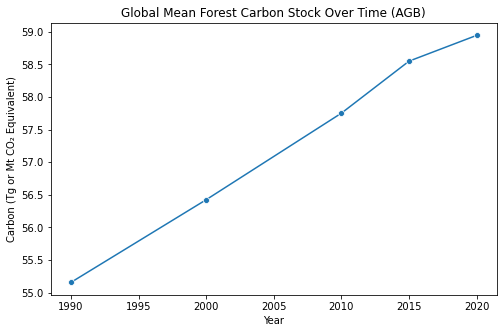

In [24]:
carbon_cols = ["carbon_1990", "carbon_2000", "carbon_2010", "carbon_2015", "carbon_2020"]

df_carbon_long = df_agb.melt(
    id_vars=["country"], value_vars=carbon_cols,
    var_name="Year", value_name="Carbon"
)

df_carbon_long["Year"] = df_carbon_long["Year"].str.extract("(\d+)").astype(int)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_carbon_long.groupby("Year", as_index=False).mean(),
    x="Year", y="Carbon", marker="o"
)
plt.title("Global Mean Forest Carbon Stock Over Time (AGB)")
plt.xlabel("Year")
plt.ylabel("Carbon (Tg or Mt CO₂ Equivalent)")
plt.show()

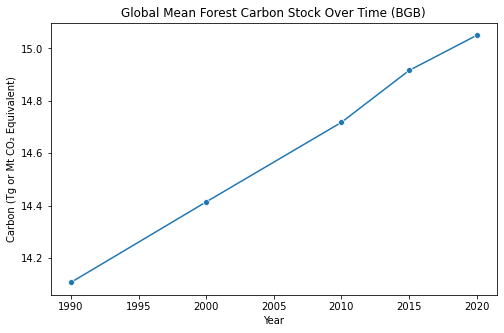

In [25]:
carbon_cols = ["carbon_1990", "carbon_2000", "carbon_2010", "carbon_2015", "carbon_2020"]

df_carbon_long = df_bgb.melt(
    id_vars=["country"], value_vars=carbon_cols,
    var_name="Year", value_name="Carbon"
)

df_carbon_long["Year"] = df_carbon_long["Year"].str.extract("(\d+)").astype(int)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_carbon_long.groupby("Year", as_index=False).mean(),
    x="Year", y="Carbon", marker="o"
)
plt.title("Global Mean Forest Carbon Stock Over Time (BGB)")
plt.xlabel("Year")
plt.ylabel("Carbon (Tg or Mt CO₂ Equivalent)")
plt.show()

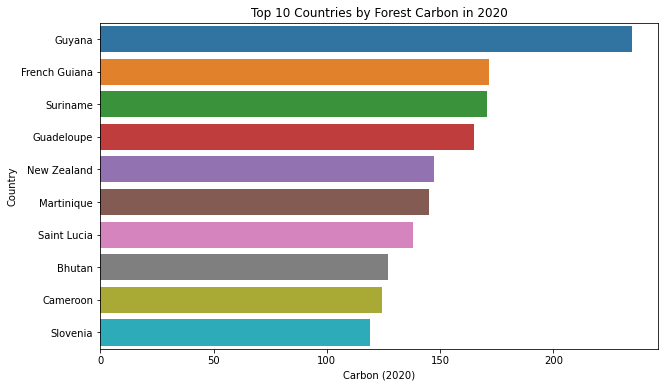

In [26]:
top10 = df_agb.nlargest(10, "carbon_2020")[["country", "carbon_2020"]]

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="carbon_2020", y="country")
plt.title("Top 10 Countries by Forest Carbon in 2020")
plt.xlabel("Carbon (2020)")
plt.ylabel("Country")
plt.show()

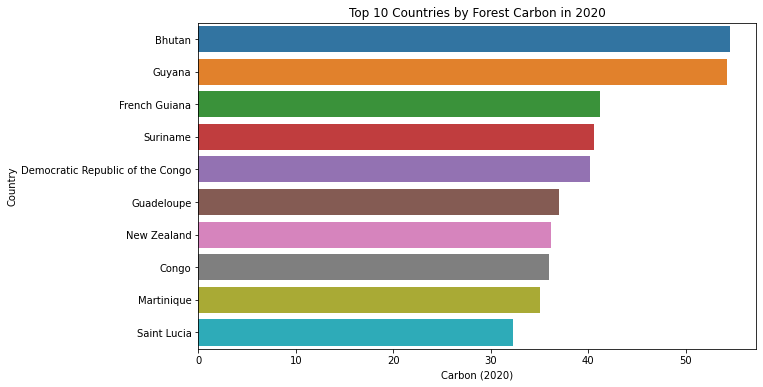

In [27]:
top10 = df_bgb.nlargest(10, "carbon_2020")[["country", "carbon_2020"]]

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="carbon_2020", y="country")
plt.title("Top 10 Countries by Forest Carbon in 2020")
plt.xlabel("Carbon (2020)")
plt.ylabel("Country")
plt.show()

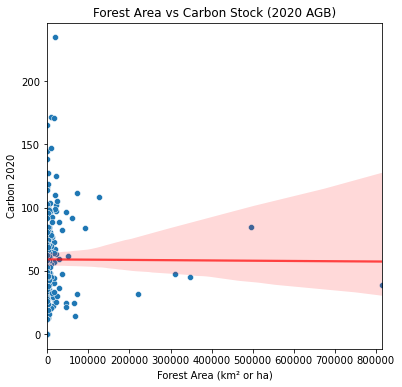

In [28]:
plt.figure(figsize=(6,6))
sns.scatterplot(data=df_agb, x="forest_area_2020", y="carbon_2020")
sns.regplot(data=df_agb, x="forest_area_2020", y="carbon_2020",
            scatter=False, color="red", line_kws={"alpha":0.7})
plt.title("Forest Area vs Carbon Stock (2020 AGB)")
plt.xlabel("Forest Area (km² or ha)")
plt.ylabel("Carbon 2020")
plt.show()

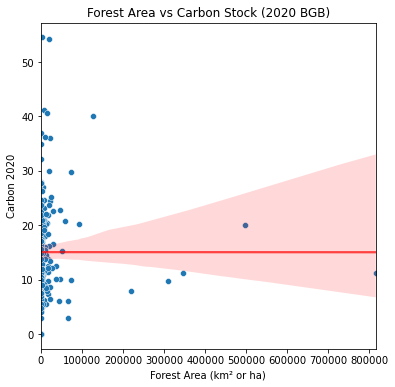

In [29]:
plt.figure(figsize=(6,6))
sns.scatterplot(data=df_bgb, x="forest_area_2020", y="carbon_2020")
sns.regplot(data=df_bgb, x="forest_area_2020", y="carbon_2020",
            scatter=False, color="red", line_kws={"alpha":0.7})
plt.title("Forest Area vs Carbon Stock (2020 BGB)")
plt.xlabel("Forest Area (km² or ha)")
plt.ylabel("Carbon 2020")
plt.show()

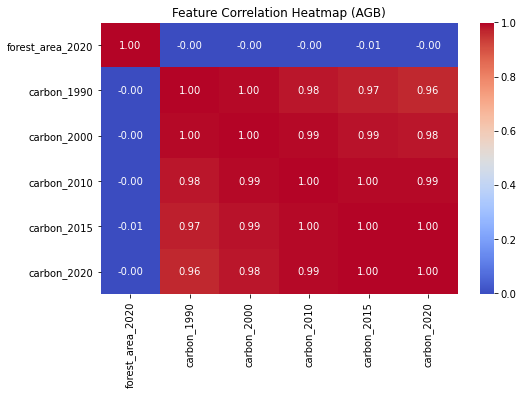

In [30]:
plt.figure(figsize=(8,5))
sns.heatmap(df_agb.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap (AGB)")
plt.show()

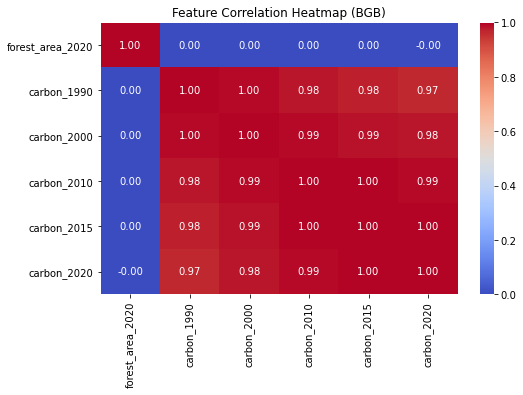

In [31]:
plt.figure(figsize=(8,5))
sns.heatmap(df_bgb.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap (BGB)")
plt.show()

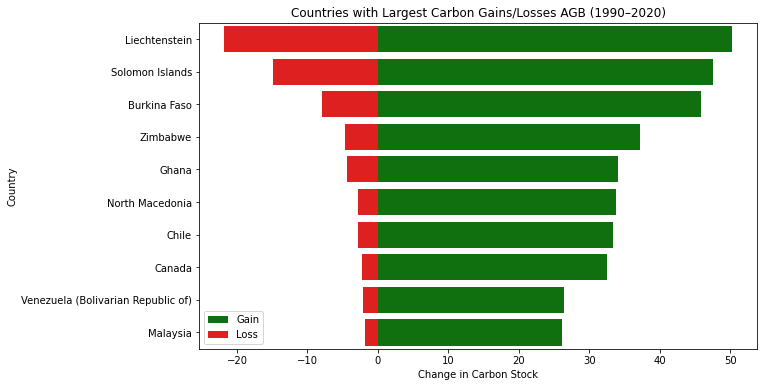

In [32]:
df_agb["carbon_change"] = df_agb["carbon_2020"] - df_agb["carbon_1990"]

plt.figure(figsize=(10,6))
top_gain = df_agb.nlargest(10, "carbon_change")
top_loss = df_agb.nsmallest(10, "carbon_change")

sns.barplot(data=top_gain, x="carbon_change", y="country", color="green", label="Gain")
sns.barplot(data=top_loss, x="carbon_change", y="country", color="red", label="Loss")
plt.title("Countries with Largest Carbon Gains/Losses AGB (1990–2020)")
plt.xlabel("Change in Carbon Stock")
plt.ylabel("Country")
plt.legend()
plt.show()

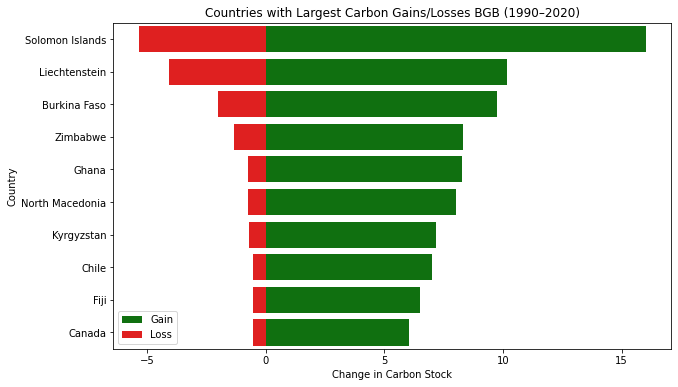

In [33]:
df_bgb["carbon_change"] = df_bgb["carbon_2020"] - df_bgb["carbon_1990"]

plt.figure(figsize=(10,6))
top_gain = df_bgb.nlargest(10, "carbon_change")
top_loss = df_bgb.nsmallest(10, "carbon_change")

sns.barplot(data=top_gain, x="carbon_change", y="country", color="green", label="Gain")
sns.barplot(data=top_loss, x="carbon_change", y="country", color="red", label="Loss")
plt.title("Countries with Largest Carbon Gains/Losses BGB (1990–2020)")
plt.xlabel("Change in Carbon Stock")
plt.ylabel("Country")
plt.legend()
plt.show()

## 1.2 - NOAA: Global Summary of the Year (GSOY)

In [34]:
df_gsoy = spark.read.option("header", True).csv(f"{HDFS_BASE}/data/data/*.csv")

In [35]:
df_gsoy.write.mode("overwrite").parquet(f"{HDFS_BASE}/work/nbs/parquets/dirty_gsoy.parquet")

df_gsoy = spark.read.parquet(f"{HDFS_BASE}/work/nbs/parquets/dirty_gsoy.parquet")

### 1.2.1 - Data Preprocessing

In [36]:
def clean_gsoy(df_gsoy, country_csv_path):
    import math
    from pyspark.sql import functions as F, types as T

    centroids = (
        spark.read.option("header", True).csv(country_csv_path)
        .selectExpr("float(latitude) as lat", "float(longitude) as lon", "Country as country")
        .collect()
    )

    def nearest_country(lat, lon):
        if lat is None or lon is None:
            return None
        best = None
        best_dist = float("inf")
        for c in centroids:
            d = math.sqrt((lat - c.lat)**2 + (lon - c.lon)**2)
            if d < best_dist:
                best, best_dist = c.country, d
        return best

    nearest_country_udf = F.udf(nearest_country, T.StringType())

    keep_cols = [
        "STATION", "DATE", "LATITUDE", "LONGITUDE", "ELEVATION",
        "TAVG", "TMIN", "TMAX", "EMXT", "EMNT", "PRCP", "EMXP",
        "DP01", "DP10", "DP1X", "AWND", "CLDD", "HTDD", "FZF0"
    ]
    df = df_gsoy.select([c for c in df_gsoy.columns if c in keep_cols])

    df = (
        df.withColumn("LATITUDE", F.col("LATITUDE").cast(T.FloatType()))
          .withColumn("LONGITUDE", F.col("LONGITUDE").cast(T.FloatType()))
          .withColumn("YEAR", F.col("DATE").cast(T.IntegerType()))
    )

    df = df.filter(
        F.col("LATITUDE").isNotNull() &
        F.col("LONGITUDE").isNotNull() &
        F.col("LATITUDE").between(-90, 90) &
        F.col("LONGITUDE").between(-180, 180)
    )

    df = df.withColumn("COUNTRY", nearest_country_udf("LATITUDE", "LONGITUDE"))

    df_country_year = (
        df.groupBy("COUNTRY", "YEAR")
        .agg(
            F.avg("TAVG").alias("avg_temp"),
            F.avg("TMIN").alias("avg_tmin"),
            F.avg("TMAX").alias("avg_tmax"),
            F.avg("PRCP").alias("avg_precip"),
            F.avg("AWND").alias("avg_wind"),
            F.avg("CLDD").alias("avg_cooling_deg_days"),
            F.avg("HTDD").alias("avg_heating_deg_days"),
            F.avg("FZF0").alias("avg_first_freeze")
        )
    )

    df_decadal = (
        df_country_year
        .withColumn(
            "TARGET_YEAR",
            F.when(F.col("YEAR").between(1986, 1990), 1990)
             .when(F.col("YEAR").between(1996, 2000), 2000)
             .when(F.col("YEAR").between(2006, 2010), 2010)
             .when(F.col("YEAR").between(2011, 2015), 2015)
             .when(F.col("YEAR").between(2016, 2020), 2020)
        )
        .filter("TARGET_YEAR is not null")
        .groupBy("COUNTRY", "TARGET_YEAR")
        .agg(*[
            F.avg(c).alias(c) for c in [
                "avg_temp", "avg_tmin", "avg_tmax", "avg_precip", "avg_wind",
                "avg_cooling_deg_days", "avg_heating_deg_days", "avg_first_freeze"
            ]
        ])
    )

    return df_decadal

df_gsoy_clean = clean_gsoy(df_gsoy, f"{HDFS_BASE}/country_coordinates.csv")

In [37]:
df_gsoy_clean.write.mode("overwrite").parquet(f"{HDFS_BASE}/work/nbs/parquets/unimputed_gsoy_decadal.parquet")

df_gsoy_clean = spark.read.parquet(f"{HDFS_BASE}/work/nbs/parquets/unimputed_gsoy_decadal.parquet")

In [38]:
from pyspark.sql import Window

In [39]:
impute_cols = [
    "avg_temp", "avg_tmin", "avg_tmax", "avg_precip",
    "avg_wind", "avg_cooling_deg_days",
    "avg_heating_deg_days", "avg_first_freeze"
]

country_window = Window.partitionBy("COUNTRY")

for col_name in impute_cols:
    df_gsoy_clean = df_gsoy_clean.withColumn(
        col_name,
        F.when(
            F.col(col_name).isNotNull(),
            F.col(col_name)
        ).otherwise(F.avg(F.col(col_name)).over(country_window))
    )

In [40]:
global_means = df_gsoy_clean.agg(
    *[F.avg(F.col(c)).alias(c) for c in impute_cols]
).collect()[0]

for c in impute_cols:
    df_gsoy_clean = df_gsoy_clean.na.fill({c: global_means[c]})

In [41]:
df_gsoy_clean.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_gsoy_clean.columns]).show()

+-------+-----------+--------+--------+--------+----------+--------+--------------------+--------------------+----------------+
|COUNTRY|TARGET_YEAR|avg_temp|avg_tmin|avg_tmax|avg_precip|avg_wind|avg_cooling_deg_days|avg_heating_deg_days|avg_first_freeze|
+-------+-----------+--------+--------+--------+----------+--------+--------------------+--------------------+----------------+
|      0|          0|       0|       0|       0|         0|       0|                   0|                   0|               0|
+-------+-----------+--------+--------+--------+----------+--------+--------------------+--------------------+----------------+



In [42]:
df_gsoy_clean.describe().show()

+-------+-----------+------------------+------------------+------------------+------------------+-------------------+------------------+--------------------+--------------------+------------------+
|summary|    COUNTRY|       TARGET_YEAR|          avg_temp|          avg_tmin|          avg_tmax|         avg_precip|          avg_wind|avg_cooling_deg_days|avg_heating_deg_days|  avg_first_freeze|
+-------+-----------+------------------+------------------+------------------+------------------+-------------------+------------------+--------------------+--------------------+------------------+
|  count|        939|               939|               939|               939|               939|                939|               939|                 939|                 939|               939|
|   mean|       null|2006.6453674121406| 41.49275025206852|1166.4311342950807|5043.7140172596955|  272.6645603370446| 583.3869077985512|  163.60270981539506|  2114.3866631978667|270.03005886367066|
| stddev| 

In [43]:
df_gsoy_clean.write.mode("overwrite").parquet(f"{HDFS_BASE}/work/nbs/parquets/imputed_gsoy_decadal.parquet")

df_gsoy_clean_imputed = spark.read.parquet(f"{HDFS_BASE}/work/nbs/parquets/imputed_gsoy_decadal.parquet")

### 1.2.2 - EDA

In [45]:
df_gsoy_clean.printSchema()

root
 |-- COUNTRY: string (nullable = true)
 |-- TARGET_YEAR: integer (nullable = true)
 |-- avg_temp: double (nullable = false)
 |-- avg_tmin: double (nullable = false)
 |-- avg_tmax: double (nullable = false)
 |-- avg_precip: double (nullable = false)
 |-- avg_wind: double (nullable = false)
 |-- avg_cooling_deg_days: double (nullable = false)
 |-- avg_heating_deg_days: double (nullable = false)
 |-- avg_first_freeze: double (nullable = false)



In [46]:
country_counts = df_gsoy_clean.groupBy("COUNTRY").count().orderBy(F.desc("count"))
country_counts.show(10)

+--------------------+-----+
|             COUNTRY|count|
+--------------------+-----+
|         Philippines|    5|
|              Jersey|    5|
|             Eritrea|    5|
|Falkland Islands ...|    5|
|               Yemen|    5|
|Svalbard and Jan ...|    5|
|              Sweden|    5|
|            Paraguay|    5|
|            Kiribati|    5|
|              Russia|    5|
+--------------------+-----+
only showing top 10 rows



In [47]:
gsoy_sample_df = df_gsoy_clean.sample(fraction=0.1, seed=42).toPandas()

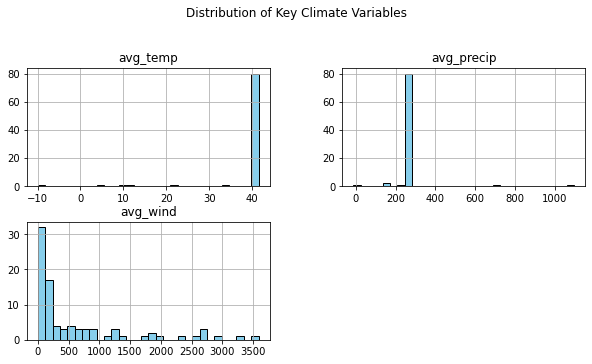

In [48]:
cols_to_plot = ["avg_temp", "avg_precip", "avg_wind"]

gsoy_sample_df[cols_to_plot].hist(bins=30, figsize=(10,5), color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Key Climate Variables", y=1.05)
plt.show()

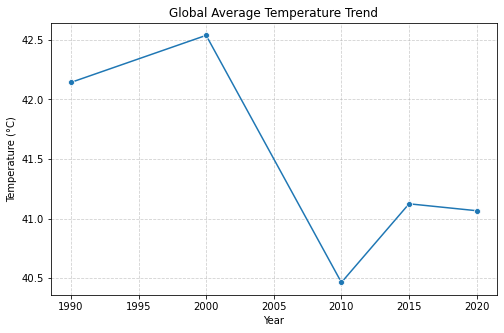

In [49]:
gsoy_trend_df = (
    df_gsoy_clean.groupBy("TARGET_YEAR")
    .agg(F.avg("avg_temp").alias("mean_temp"))
    .orderBy("TARGET_YEAR")
    .toPandas()
)

plt.figure(figsize=(8,5))
sns.lineplot(data=gsoy_trend_df, x="TARGET_YEAR", y="mean_temp", marker="o")
plt.title("Global Average Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

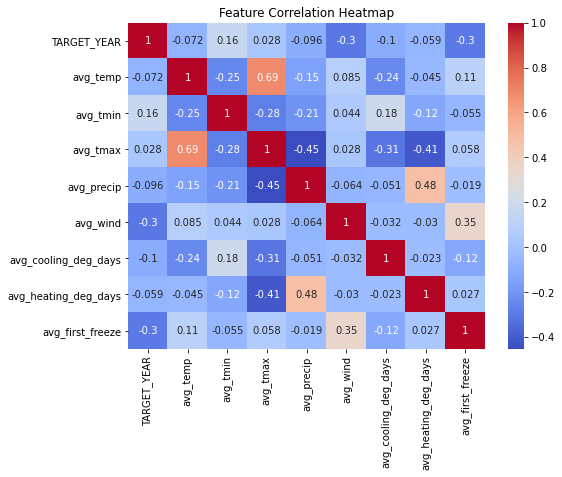

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(gsoy_sample_df.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

## 1.3 - OWID: CO2 Emissions

In [52]:
df_owid = spark.read.csv(
    f"{HDFS_BASE}/co2-emissions-per-capita.csv",
    header=True,
    inferSchema=True
)

## 1.3.1 - Data Preprocessing

In [53]:
from pyspark.sql import types as T

df_owid = (
    df_owid
    .withColumnRenamed("Entity", "country")
    .withColumnRenamed("Year", "year")
    .withColumnRenamed("Annual CO₂ emissions (per capita)", "co2_per_capita")
)

df_owid = df_owid.select("country", "year", "co2_per_capita")

df_owid = (
    df_owid
    .dropna(subset=["country", "year", "co2_per_capita"])
    .filter(F.col("co2_per_capita") >= 0)
)

exclude_keywords = ["World", "Europe", "Asia", "Africa", "America", "income", "OECD", "International", "countries"]
pattern = "|".join(exclude_keywords)
df_owid = df_owid.filter(~F.lower(F.col("country")).rlike(pattern.lower()))

df_owid = (
    df_owid
    .withColumn("year", F.col("year").cast(T.IntegerType()))
    .withColumn("co2_per_capita", F.col("co2_per_capita").cast(T.FloatType()))
)

target_years = [1990, 2000, 2010, 2015, 2020]
df_owid = df_owid.filter(F.col("year").isin(target_years))

df_owid_pivot = (
    df_owid.groupBy("country")
    .pivot("year", target_years)
    .agg(F.first("co2_per_capita"))
)

for y in target_years:
    df_owid_pivot = df_owid_pivot.withColumnRenamed(str(y), f"co2_percap_{y}")

In [54]:
df_owid_pivot.show(5)

+--------+---------------+---------------+---------------+---------------+---------------+
| country|co2_percap_1990|co2_percap_2000|co2_percap_2010|co2_percap_2015|co2_percap_2020|
+--------+---------------+---------------+---------------+---------------+---------------+
|    Chad|      0.0630791|    0.057272878|     0.10038562|     0.16055147|     0.13680632|
|Anguilla|       5.655664|      6.8724546|       9.864194|       9.780962|       9.613563|
|Paraguay|     0.52918017|      0.7069634|      0.8751859|     0.98245007|      1.1171615|
|  Russia|      17.024136|      10.081548|      11.343935|      11.277285|     11.1560755|
|   Macao|       2.567032|       3.493785|       2.193938|        2.84435|      1.5126553|
+--------+---------------+---------------+---------------+---------------+---------------+
only showing top 5 rows



In [55]:
df_owid_pivot.printSchema()

root
 |-- country: string (nullable = true)
 |-- co2_percap_1990: float (nullable = true)
 |-- co2_percap_2000: float (nullable = true)
 |-- co2_percap_2010: float (nullable = true)
 |-- co2_percap_2015: float (nullable = true)
 |-- co2_percap_2020: float (nullable = true)



In [56]:
df_owid_pivot.write.mode("overwrite").parquet(f"{HDFS_BASE}/work/nbs/parquets/pivot_owid_pivot.parquet")

df_owid_clean = spark.read.parquet(f"{HDFS_BASE}/work/nbs/parquets/pivot_owid_pivot.parquet")

### 1.3.2 - EDA

In [57]:
df_owid_pd = df_owid_clean.toPandas()

In [58]:
print("Shape:", df_owid_pd.shape)
print("Columns:", df_owid_pd.columns.tolist())
print("\nMissing values:\n", df_owid_pd.isnull().sum())
display(df_owid_pd.describe())

Shape: (213, 6)
Columns: ['country', 'co2_percap_1990', 'co2_percap_2000', 'co2_percap_2010', 'co2_percap_2015', 'co2_percap_2020']

Missing values:
 country            0
co2_percap_1990    6
co2_percap_2000    0
co2_percap_2010    0
co2_percap_2015    0
co2_percap_2020    0
dtype: int64


,co2_percap_1990,co2_percap_2000,co2_percap_2010,co2_percap_2015,co2_percap_2020
count,207.000000,213.000000,213.000000,213.000000,213.000000
mean,5.042040,5.049417,5.256925,5.032842,4.515060
std,6.235843,7.208891,6.593472,6.344274,5.351325
min,0.036950,0.000000,0.035169,0.032171,0.035867
25%,0.468287,0.699062,0.778716,0.906001,0.971832
50%,2.567032,2.545863,2.793193,2.926817,2.966649
75%,7.557821,6.872455,7.183918,6.580193,5.711102
max,30.972353,62.503780,42.955734,44.002041,36.563511


In [59]:
df_long = df_owid_pd.melt(
    id_vars="country",
    value_vars=[c for c in df_owid_pd.columns if "co2_percap" in c],
    var_name="year",
    value_name="co2_percap"
)

df_long["year"] = df_long["year"].str.extract(r"(\d{4})").astype(int)

df_long = df_long.dropna(subset=["co2_percap"])

print(df_long["year"].unique())

[1990 2000 2010 2015 2020]


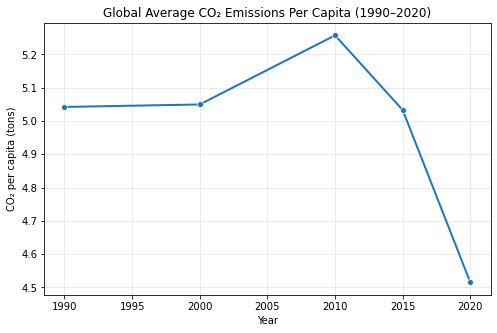

In [60]:
global_trend = df_long.groupby("year", as_index=False)["co2_percap"].mean()

plt.figure(figsize=(8,5))
sns.lineplot(data=global_trend, x="year", y="co2_percap", marker="o", linewidth=2)
plt.title("Global Average CO₂ Emissions Per Capita (1990–2020)")
plt.xlabel("Year")
plt.ylabel("CO₂ per capita (tons)")
plt.grid(alpha=0.3)
plt.show()

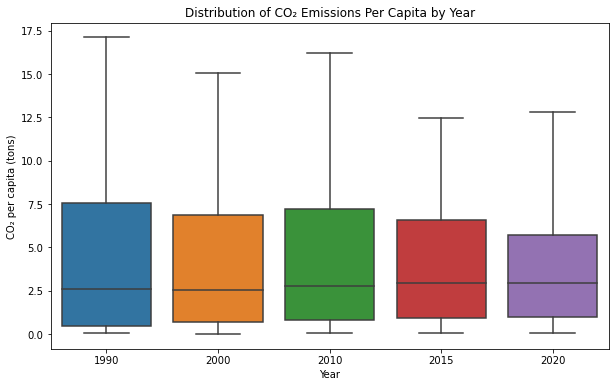

In [61]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_long, x="year", y="co2_percap", showfliers=False)
plt.title("Distribution of CO₂ Emissions Per Capita by Year")
plt.xlabel("Year")
plt.ylabel("CO₂ per capita (tons)")
plt.show()

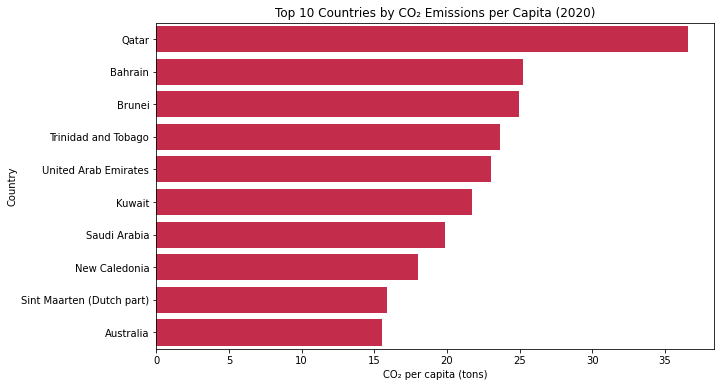

In [62]:
top10 = df_owid_pd.nlargest(10, "co2_percap_2020")[["country", "co2_percap_2020"]]

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="co2_percap_2020", y="country", color="crimson")
plt.title("Top 10 Countries by CO₂ Emissions per Capita (2020)")
plt.xlabel("CO₂ per capita (tons)")
plt.ylabel("Country")
plt.show()

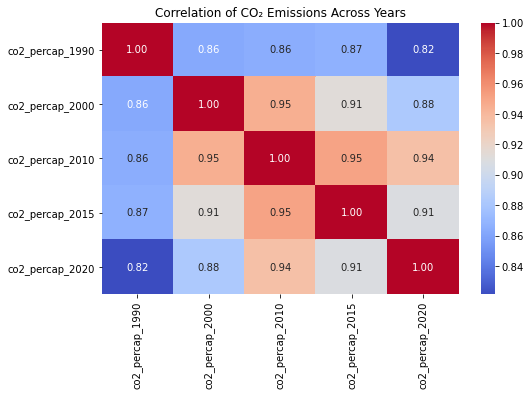

In [63]:
plt.figure(figsize=(8,5))
sns.heatmap(df_owid_pd.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation of CO₂ Emissions Across Years")
plt.show()

In [64]:
df_long.groupby("year")["co2_percap"].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
1990,207.0,5.042040,6.235843,0.036950,0.468287,2.567032,7.557821,30.972353
2000,213.0,5.049417,7.208891,0.000000,0.699062,2.545863,6.872455,62.503780
2010,213.0,5.256925,6.593472,0.035169,0.778716,2.793193,7.183918,42.955734
2015,213.0,5.032842,6.344274,0.032171,0.906001,2.926817,6.580193,44.002041
2020,213.0,4.515060,5.351325,0.035867,0.971832,2.966649,5.711102,36.563511


# 2 - Join and Split Data

In [65]:
df_gsoy = df_gsoy_clean.withColumnRenamed("COUNTRY", "country") \
                       .withColumnRenamed("TARGET_YEAR", "year")

In [66]:
df_agb_long = (
    df_agb_spark.selectExpr(
        "country",
        "stack(5, '1990', carbon_1990, '2000', carbon_2000, '2010', carbon_2010, '2015', carbon_2015, '2020', carbon_2020) as (year, carbon_agb)"
    )
    .withColumn("year", F.col("year").cast("int"))
)

df_bgb_long = (
    df_bgb_spark.selectExpr(
        "country",
        "stack(5, '1990', carbon_1990, '2000', carbon_2000, '2010', carbon_2010, '2015', carbon_2015, '2020', carbon_2020) as (year, carbon_bgb)"
    )
    .withColumn("year", F.col("year").cast("int"))
)

df_owid_long = (
    df_owid_pivot.selectExpr(
        "country",
        "stack(5, '1990', co2_percap_1990, '2000', co2_percap_2000, '2010', co2_percap_2010, '2015', co2_percap_2015, '2020', co2_percap_2020) as (year, co2_percap)"
    )
    .withColumn("year", F.col("year").cast("int"))
)

In [67]:
df_joined = (
    df_gsoy.join(df_agb_long, on=["country", "year"], how="inner")
           .join(df_bgb_long, on=["country", "year"], how="inner")
           .join(df_owid_long, on=["country", "year"], how="inner")
)

In [68]:
df_joined = df_joined.withColumn(
    "carbon_total", 
    F.col("carbon_agb") + F.col("carbon_bgb")
)

In [69]:
df_joined.write.mode("overwrite").parquet(f"{HDFS_BASE}/work/nbs/parquets/df_joined.parquet")

df_joined = spark.read.parquet(f"{HDFS_BASE}/work/nbs/parquets/df_joined.parquet")

In [70]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

df_joined.show(5)

+-------+----+------------------+------------------+------------------+------------------+-----------------+--------------------+--------------------+------------------+----------+----------+----------+------------+
|country|year|          avg_temp|          avg_tmin|          avg_tmax|        avg_precip|         avg_wind|avg_cooling_deg_days|avg_heating_deg_days|  avg_first_freeze|carbon_agb|carbon_bgb|co2_percap|carbon_total|
+-------+----+------------------+------------------+------------------+------------------+-----------------+--------------------+--------------------+------------------+----------+----------+----------+------------+
|Bahamas|2000| 35.77329243815381| 763.8550614174625| 46.91436242068759| 169.1479230143735|613.4716605340034|  221.64046390585122|   523.7928729321131|16.738462861516474|     18.71|      7.48|  6.256653|       26.19|
|Bahamas|2010| 41.39354498087507|169.96918392306128|1749.6010121572322|182.44636429277375|571.0173280702014|   233.5271740832415|   530.

In [71]:
df_joined.printSchema()

root
 |-- country: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_tmin: double (nullable = true)
 |-- avg_tmax: double (nullable = true)
 |-- avg_precip: double (nullable = true)
 |-- avg_wind: double (nullable = true)
 |-- avg_cooling_deg_days: double (nullable = true)
 |-- avg_heating_deg_days: double (nullable = true)
 |-- avg_first_freeze: double (nullable = true)
 |-- carbon_agb: double (nullable = true)
 |-- carbon_bgb: double (nullable = true)
 |-- co2_percap: float (nullable = true)
 |-- carbon_total: double (nullable = true)



In [85]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

feature_cols = ["avg_temp", "avg_precip", "avg_wind", "co2_percap"]
label_col = "carbon_total"

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_vec")
scaler = StandardScaler(inputCol="features_vec", outputCol="features", withMean=True, withStd=True)

df_model = df_joined.select(feature_cols + [label_col]).dropna()

train_df, test_df = df_model.randomSplit([0.7, 0.3], seed=42)

evaluator = RegressionEvaluator(labelCol=label_col, predictionCol="prediction",
                                metricName="r2")
rmse_eval = RegressionEvaluator(labelCol=label_col, predictionCol="prediction",
                                metricName="rmse")

# 3 - Machine Learning Models

## 3.1 - Linear Regression

In [86]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol=label_col)
pipeline_lr = Pipeline(stages=[assembler, scaler, lr])

model_lr = pipeline_lr.fit(train_df)
pred_lr = model_lr.transform(test_df)

r2_lr = evaluator.evaluate(pred_lr)
rmse_lr = rmse_eval.evaluate(pred_lr)

In [87]:
print(f"Linear Regression — R²: {r2_lr:.3f}, RMSE: {rmse_lr:.3f}")

Linear Regression — R²: 0.091, RMSE: 39.864


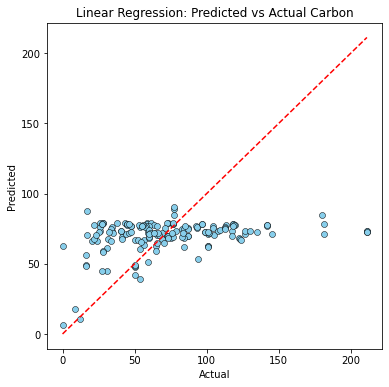

In [88]:
pdf_lr = pred_lr.select("carbon_total", "prediction").toPandas()
plt.figure(figsize=(6,6))
sns.scatterplot(data=pdf_lr, x="carbon_total", y="prediction", color="skyblue", edgecolor="black")
plt.plot([pdf_lr.min().min(), pdf_lr.max().max()],
         [pdf_lr.min().min(), pdf_lr.max().max()],
         'r--')
plt.title("Linear Regression: Predicted vs Actual Carbon")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 3.2 - Random Forest

In [89]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(featuresCol="features", labelCol=label_col,
                           numTrees=50, maxDepth=5)
pipeline_rf = Pipeline(stages=[assembler, scaler, rf])
model_rf = pipeline_rf.fit(train_df)
pred_rf = model_rf.transform(test_df)

r2_rf = evaluator.evaluate(pred_rf)
rmse_rf = rmse_eval.evaluate(pred_rf)
print(f"Random Forest — R²: {r2_rf:.3f}, RMSE: {rmse_rf:.3f}")

Random Forest — R²: 0.240, RMSE: 36.452


      Feature  Importance
3  co2_percap    0.393194
2    avg_wind    0.259299
0    avg_temp    0.258695
1  avg_precip    0.088811


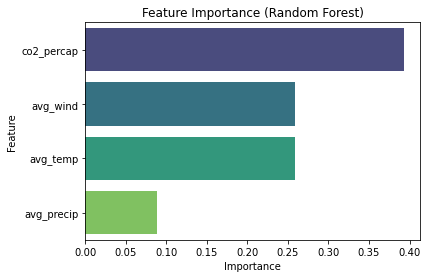

In [90]:
fi = model_rf.stages[-1].featureImportances
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": fi.toArray()
}).sort_values("Importance", ascending=False)

print(feature_importance)
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()

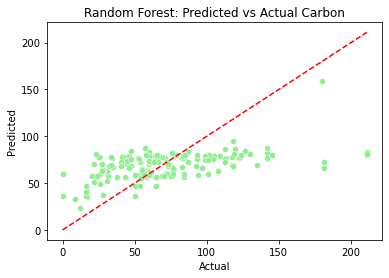

In [91]:
pdf_rf = pred_rf.select("carbon_total", "prediction").toPandas()
sns.scatterplot(data=pdf_rf, x="carbon_total", y="prediction", color="lightgreen")
plt.plot([pdf_rf.min().min(), pdf_rf.max().max()],
         [pdf_rf.min().min(), pdf_rf.max().max()],
         'r--')
plt.title("Random Forest: Predicted vs Actual Carbon")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 3.3 - PCA

In [92]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(featuresCol="features", k=4, seed=1)
pipeline_km = Pipeline(stages=[assembler, scaler, kmeans])
model_km = pipeline_km.fit(train_df)

pred_km = model_km.transform(test_df)

In [98]:
pred_km.groupBy("Prediction").agg(
    F.count("*").alias("Count"),
    F.avg("carbon_total").alias("Avg_Carbon")
).show()

+----------+-----+------------------+
|Prediction|Count|        Avg_Carbon|
+----------+-----+------------------+
|         1|    2|             10.56|
|         3|   49|60.439183673469394|
|         2|    2|29.185000000000002|
|         0|  116| 79.85594827586208|
+----------+-----+------------------+



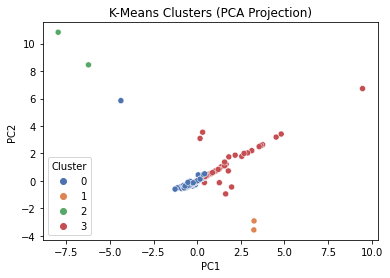

In [94]:
from pyspark.ml.feature import PCA

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(pred_km)
df_pca = pca_model.transform(pred_km)

pdf_pca = df_pca.select("pca_features", "prediction").toPandas()

pca_array = pdf_pca["pca_features"].apply(lambda v: v.toArray())
pca_data = pd.DataFrame(pca_array.tolist(), columns=["PC1", "PC2"])
pca_data["Cluster"] = pdf_pca["prediction"]

sns.scatterplot(data=pca_data, x="PC1", y="PC2", hue="Cluster", palette="deep")
plt.title("K-Means Clusters (PCA Projection)")
plt.show()

## 3.4 - Gradient Boosted Trees

In [95]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(featuresCol="features", labelCol=label_col, maxIter=50)
pipeline_gbt = Pipeline(stages=[assembler, scaler, gbt])
model_gbt = pipeline_gbt.fit(train_df)
pred_gbt = model_gbt.transform(test_df)

r2_gbt = evaluator.evaluate(pred_gbt)
rmse_gbt = rmse_eval.evaluate(pred_gbt)
print(f"Gradient Boosted Trees — R²: {r2_gbt:.3f}, RMSE: {rmse_gbt:.3f}")

Gradient Boosted Trees — R²: 0.101, RMSE: 39.650


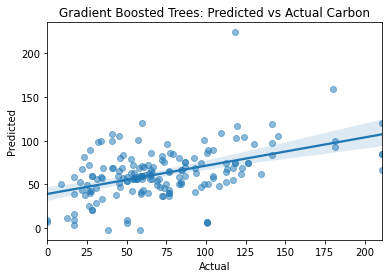

In [96]:
pdf_gbt = pred_gbt.select("carbon_total", "prediction").toPandas()
sns.regplot(data=pdf_gbt, x="carbon_total", y="prediction", scatter_kws={'alpha':0.5})
plt.title("Gradient Boosted Trees: Predicted vs Actual Carbon")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

               Model        R²       RMSE
0  Linear Regression  0.091164  39.863524
1      Random Forest  0.240056  36.452195
2      GBT Regressor  0.100888  39.649711


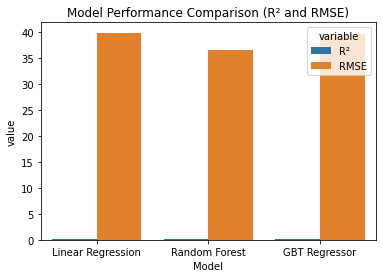

In [97]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "GBT Regressor"],
    "R²": [r2_lr, r2_rf, r2_gbt],
    "RMSE": [rmse_lr, rmse_rf, rmse_gbt]
})
print(results)
sns.barplot(data=results.melt(id_vars="Model"), x="Model", y="value", hue="variable")
plt.title("Model Performance Comparison (R² and RMSE)")
plt.show()

# 4 - Conclusion

The train and test data was split 70% and 30% respectively. R² measures how well the model explains the variance in the target variable, while RMSE quantifies the average prediction error — lower RMSE and higher R² indicate better performance. With that, Linear Regression scored R²: 0.091 and RMSE: 39.864, performing modestly as a baseline model. Random Forest found that the highest indicator of absorbed carbon was CO₂ per capita and was able to predict with R²: 0.240 and RMSE: 36.452, showing improved accuracy through non-linear relationships. PCA reduced the feature space to two principal components for visualising the spread of climate and emission variables, highlighting clear clustering patterns among regions. The Gradient Boosted Trees performed with R²: 0.101 and RMSE: 39.650, capturing some complex interactions but with limited gain over the baseline. The best performing model was Random Forest, most likely because ensemble methods handle variable interactions and outliers more effectively, while simpler models struggled to capture non-linear dependencies. In conclusion, further research would have to be done to take on the complexity of forest ecosystems that limit precise prediction accuracy.